# 01 — Inspecting and Profiling a New Dataset

Companion to [`../../data_cleaning/README.md`](../../data_cleaning/README.md).

---

## Why profiling matters

Before you clean, model, or visualize — you must **understand** the data. A thorough initial inspection answers:

- **How big is this?** (rows, columns, memory footprint)
- **What lives in each column?** (types, ranges, unique values)
- **What's broken?** (missing values, sentinels, duplicates, outliers)
- **What patterns jump out?** (distributions, correlations, time gaps)

This notebook walks through a systematic first look at any new dataset. We use a synthetic customer dataset with intentionally injected problems so you can see each step in action.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(0)
n = 1000
df = pd.DataFrame({
    "user_id":   rng.integers(1000, 9999, n),
    "age":       rng.normal(38, 12, n).clip(0, 100).round(),
    "income":    rng.lognormal(10.5, 0.7, n).round(2),
    "country":   rng.choice(["US", "UK", "DE", "FR", "BR", "IN"], n, p=[.35,.15,.15,.1,.1,.15]),
    "signup_dt": pd.to_datetime("2023-01-01") + pd.to_timedelta(rng.integers(0, 700, n), unit="D"),
    "spend":     rng.exponential(120, n).round(2),
})
# inject some realistic dirt
df.loc[rng.choice(n, 50, replace=False), "income"] = np.nan
df.loc[rng.choice(n, 5,  replace=False), "age"]    = -1            # sentinel
df.loc[rng.choice(n, 10, replace=False), "country"] = " usa "
df.loc[rng.choice(n, 3,  replace=False), "spend"]  = 1e6           # outliers
df.head()

,user_id,age,income,country,signup_dt,spend
0,8654,54.0,26402.56,IN,2023-04-28,231.15
1,6732,38.0,59513.49,US,2023-10-08,64.06
2,5599,29.0,52092.60,US,2024-01-10,101.04
3,3427,40.0,58446.52,IN,2023-08-18,69.79
4,3770,41.0,45253.99,DE,2023-04-30,77.87


## 1. Shape, dtypes, memory

The `shape` tells you the dimensions. The `info()` call reveals dtypes and memory usage — critical for deciding whether you can fit the data in memory or need chunked processing.

In [2]:
print("Shape:", df.shape)
print("\nColumn dtypes and memory:")
df.info(memory_usage='deep')

Shape: (1000, 6)

Column dtypes and memory:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    1000 non-null   int64         
 1   age        1000 non-null   float64       
 2   income     950 non-null    float64       
 3   country    1000 non-null   str           
 4   signup_dt  1000 non-null   datetime64[us]
 5   spend      1000 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 89.0 KB


## 2. Per-column summary

`describe(include='all')` gives you statistics for every column type — counts, uniques, top, freq for objects; mean, std, percentiles for numerics.

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,1000.0,NaN,NaN,NaN,5642.666,1002.0,3456.0,5769.5,7872.75,9981.0,2593.402165
age,1000.0,NaN,NaN,NaN,37.683,-1.0,30.0,38.0,46.0,72.0,12.043985
income,950.0,NaN,NaN,NaN,44990.573895,4104.52,21459.39,34283.375,57214.86,239170.09,34916.165544
country,1000,7,US,332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_dt,1000,NaN,NaN,NaN,2023-12-18 09:11:31.200000,2023-01-01 00:00:00,2023-06-25 18:00:00,2024-01-01 12:00:00,2024-06-02 06:00:00,2024-11-30 00:00:00,NaN
spend,1000.0,NaN,NaN,NaN,3119.71663,0.09,32.1725,81.39,165.4,1000000.0,54710.965726


## 3. Missingness overview

Missing data is rarely random. Understanding *which* columns are affected and *how much* guides your cleaning strategy.

In [4]:
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0]

income    0.05
dtype: float64

### Missingness heatmap

This visualizes the first 200 rows. Each white dot is a missing value. Patterns here can reveal data collection issues (e.g., entire blocks of missingness in a time range).

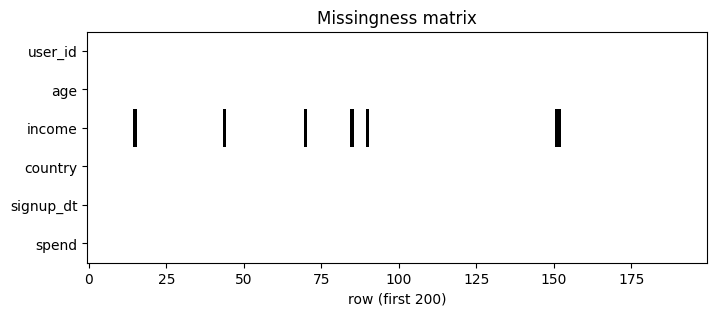

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
df.isna().astype(int).T.iloc[:, :200].pipe(lambda d: ax.imshow(d, aspect='auto', cmap='gray_r'))
ax.set_yticks(range(len(df.columns)), df.columns)
ax.set_xlabel('row (first 200)'); ax.set_title('Missingness matrix')
plt.show()

### Missingness bar chart

A horizontal bar chart makes it easy to compare missingness rates across columns at a glance.

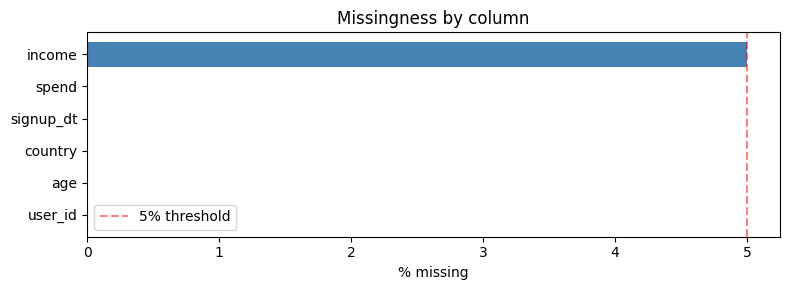

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
pct = df.isna().mean().sort_values(ascending=True)
bars = ax.barh(pct.index, pct.values * 100, color='steelblue')
ax.set_xlabel('% missing'); ax.set_title('Missingness by column')
ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Sentinel-value hunt

Sentinel values (like `-1` for age, `-999` for temperature) are placeholders that masquerade as real data. They silently corrupt statistics.

In [7]:
# Negative age?
print("Negative ages:", (df['age'] < 0).sum())
df[df['age'] < 0][['age', 'income', 'spend']].head()

Negative ages: 5


,age,income,spend
17,-1.0,15132.20,53.66
127,-1.0,224081.04,120.38
150,-1.0,21515.21,147.07
390,-1.0,17016.17,21.07
525,-1.0,32165.99,125.85


### Numeric range check

For each numeric column, we verify that the observed range falls within plausible bounds.

In [8]:
numeric_cols = df.select_dtypes(include='number').columns
range_check = pd.DataFrame({
    'min_observed': df[numeric_cols].min(),
    'max_observed': df[numeric_cols].max(),
    'mean': df[numeric_cols].mean().round(2),
    'std': df[numeric_cols].std().round(2),
})
range_check['min_plausible'] = range_check['mean'] - 4 * range_check['std']
range_check['max_plausible'] = range_check['mean'] + 4 * range_check['std']
range_check['flagged'] = (range_check['min_observed'] < range_check['min_plausible']) | \
                         (range_check['max_observed'] > range_check['max_plausible'])
range_check

,min_observed,max_observed,mean,std,min_plausible,max_plausible,flagged
user_id,1002.00,9981.00,5642.67,2593.40,-4730.93,16016.27,False
age,-1.00,72.00,37.68,12.04,-10.48,85.84,False
income,4104.52,239170.09,44990.57,34916.17,-94674.11,184655.25,True
spend,0.09,1000000.00,3119.72,54710.97,-215724.16,221963.60,True


## 5. Free-text category inspection

Categorical columns with free-text input (like country names) often have hidden inconsistencies — trailing spaces, case mismatches, typos.

In [9]:
print("Unique countries:", df['country'].nunique())
print("\nValue counts:")
df['country'].value_counts()

Unique countries: 7

Value counts:


country
US       332
UK       175
DE       144
IN       138
BR       112
FR        89
 usa      10
Name: count, dtype: int64

### Country distribution pie chart

A pie chart gives an immediate sense of class imbalance in categorical data.

/var/folders/lk/th_2s57s0jq_pvdtqfr9h2yw0000gn/T/ipykernel_95481/3477668893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax2, palette='Set2')


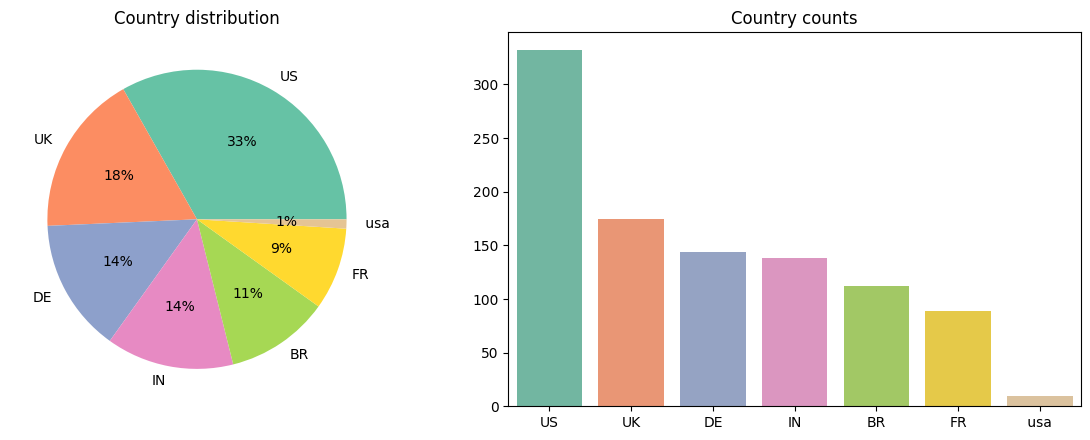

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
counts = df['country'].value_counts()
ax1.pie(counts, labels=counts.index, autopct='%1.0f%%', colors=sns.color_palette('Set2'))
ax1.set_title('Country distribution')
sns.barplot(x=counts.index, y=counts.values, ax=ax2, palette='Set2')
ax2.set_title('Country counts'); ax2.set_xlabel(''); 
plt.tight_layout(); plt.show()

## 6. Date range and gaps

Date columns can reveal temporal patterns — seasonal signups, data collection gaps, or future-dated entries.

In [11]:
date_info = df['signup_dt'].agg(['min', 'max', 'nunique'])
date_info['span_days'] = (date_info['max'] - date_info['min']).days
date_info

min          2023-01-01 00:00:00
max          2024-11-30 00:00:00
nunique                      524
span_days                    699
Name: signup_dt, dtype: object

### Signup timeline

Plotting signups over time reveals clusters, gaps, and trends.

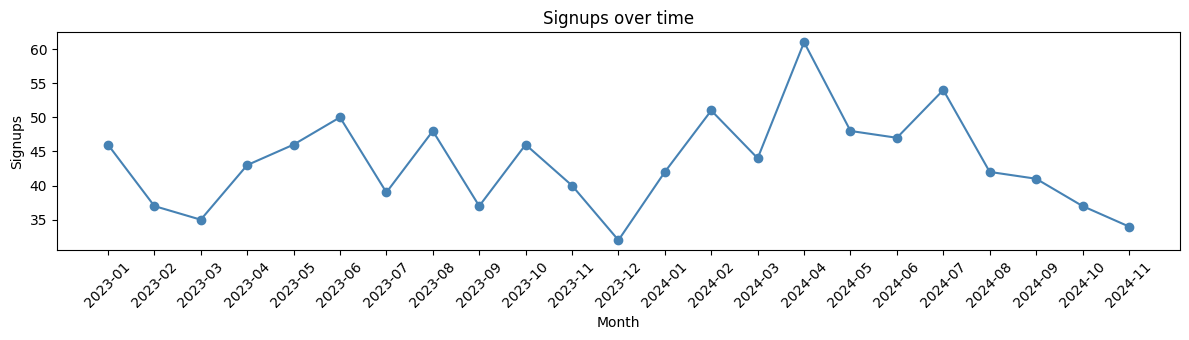

In [12]:
df['signup_month'] = df['signup_dt'].dt.to_period('M').astype(str)
monthly = df.groupby('signup_month').size()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=1.5, color='steelblue')
ax.set_xlabel('Month'); ax.set_ylabel('Signups'); ax.set_title('Signups over time')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 7. Numeric distributions — quick overview

Histograms and density plots for each numeric column give you a first look at shape, skew, and potential outliers.

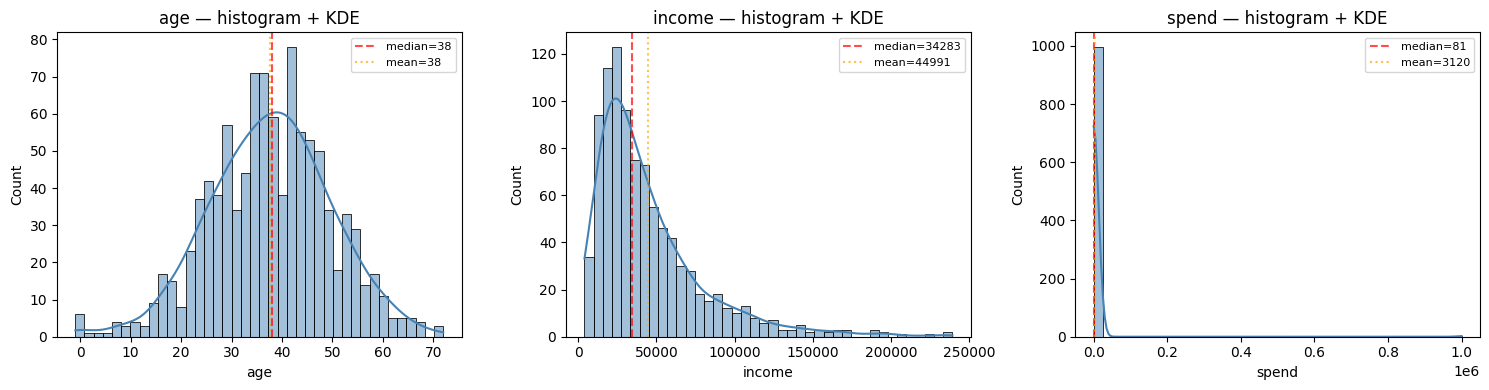

In [13]:
numeric_cols = ['age', 'income', 'spend']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=40, ax=ax, color='steelblue')
    ax.set_title(f'{col} — histogram + KDE')
    ax.axvline(df[col].median(), color='red', linestyle='--', alpha=0.7, label=f'median={df[col].median():.0f}')
    ax.axvline(df[col].mean(), color='orange', linestyle=':', alpha=0.7, label=f'mean={df[col].mean():.0f}')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Skewness check

Highly skewed distributions (|skew| > 1) often benefit from log-transforms. We flag them here.

In [14]:
skew = df[numeric_cols].skew()
print(skew.to_frame('skewness'))
print("\nInterpretation:")
for col, s in skew.items():
    label = 'highly skewed' if abs(s) > 1 else ('moderately skewed' if abs(s) > 0.5 else 'roughly symmetric')
    print(f"  {col}: {s:.2f} → {label}")

         skewness
age     -0.154096
income   1.990775
spend   18.202337

Interpretation:
  age: -0.15 → roughly symmetric
  income: 1.99 → highly skewed
  spend: 18.20 → highly skewed


## 8. Correlation heatmap

Pearson correlations between numeric columns reveal linear relationships — or the lack thereof.

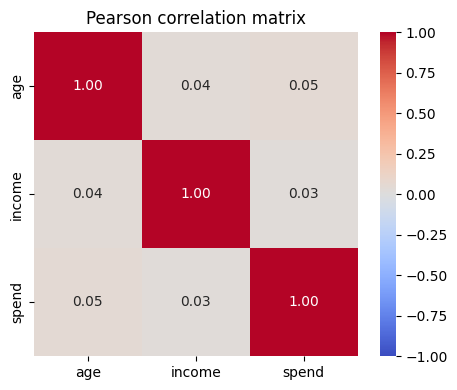

In [15]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f',
            square=True, ax=ax)
ax.set_title('Pearson correlation matrix'); plt.tight_layout(); plt.show()

## 9. Spend vs income scatter

A scatter plot with a regression line shows the relationship between two continuous variables.

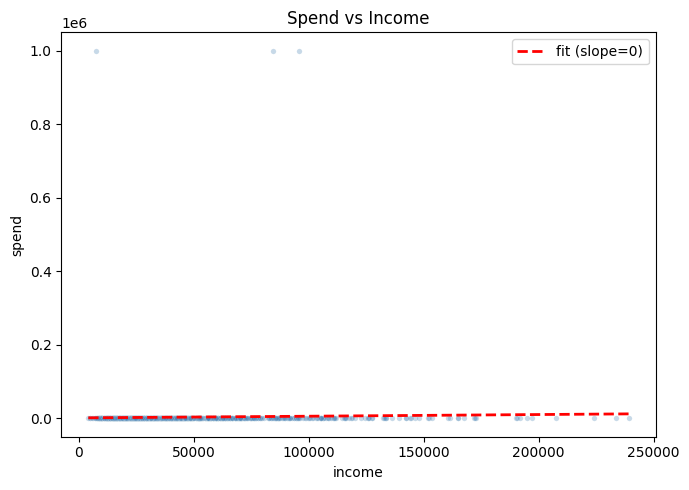

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='income', y='spend', alpha=0.3, s=15, color='steelblue', ax=ax)
xy = df[['income', 'spend']].dropna()
z = np.polyfit(xy['income'].to_numpy(), xy['spend'].to_numpy(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['income'].min(), df['income'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'fit (slope={z[0]:.0f})')
ax.set_xlabel('income'); ax.set_ylabel('spend'); ax.set_title('Spend vs Income')
ax.legend(); plt.tight_layout(); plt.show()

## What you'd do next

Based on this inspection, here's the action list:

1. **Fix sentinel `-1` for `age`** → convert to `NaN`, then impute.
2. **Normalize country variants** — strip whitespace, lowercase, then map to ISO codes.
3. **Investigate spend outliers** — are they real high-spenders or data entry errors?
4. **Handle missing income** — 5% missingness suggests imputation, not deletion.
5. **Consider log-transforms** — income and spend are highly right-skewed.

See the companion notebooks:
- [`02_missing_values.ipynb`](02_missing_values.ipynb) — imputation strategies
- [`03_outliers.ipynb`](03_outliers.ipynb) — detection and handling
- [`04_text_cleaning.ipynb`](04_text_cleaning.ipynb) — text normalization